## Identify missing oligos and plot them per label
### Outline:
1. Find number of oligos and their names `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/assignment/assignIGVFDesign/reference.fa`
2. Find all assigned oligos with the barcodes
3. Take the difference
4. How many missings per group?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import gzip

In [2]:
! pwd

/data/gpfs-1/work/users/kisa11_c/coding/80K_analysis/01_missing_sequences


In [3]:
# read in all sequences as tsv
all_seq_df = pd.read_csv('/fast/work/groups/ag_kircher/MPRA/IGVF_Y1_design/experiment/results/assignment/assignIGVFDesign/all_ref_sequences.tsv', header=None, sep='\t')
all_seq_df.columns = ['oligo_name']
# print(all_seq_df.shape) # 80214
all_seq_df

,oligo_name
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....
...,...
80210,MK:tile_2240|chr1-116244322+116244591|scramble...
80211,MK:tile_6675|chr11-2374617+2374886|scramble_ne...
80212,MK:tile_18415|chr17-71181691+71181960|scramble...
80213,MK:tile_14356|chr15-67031618+67031887|scramble...


In [4]:
# add second column which is split at first : and contains the label
all_seq_df['label'] = all_seq_df['oligo_name'].str.split(':').str[0]


In [5]:
all_seq_df
# show all unique labels
print(all_seq_df['label'].unique())
# print(len(all_seq_df['label'].unique())) # 29

['cardiac_neuro_cava_random' 'GC_Atrial_fib' 'GC_Liang' 'GC_Selvarajan'
 'GC_Mohlke' 'GC_Kircher' 'GC_Mendelian_variants' 'C_positive_heart_CAD'
 'GC_Cort_Chengyu' 'GC_GABA_Chengyu' 'GC_Glut_Chengyu' 'GC_Hon' 'GC_Vista'
 'GC_DNase_positive' 'GC_DNase_negative_brain' 'GC_DNase_negative_blood'
 'C_negative_heart_MK' 'C_negative_neuron_MK' 'C_negative_neuron_NP'
 'C_positive_heart_MK' 'C_positive_neuron_CD' 'C_positive_neuron_MK'
 'C_positive_neuron_NP' 'C_positive_heart_AB' 'C_SLEA'
 'GC_DNase_positive_shuffeled' 'GC_DNase_negative_brain_shuffeled'
 'GC_DNase_negative_blood_shuffeled' 'MK']


## Read all assigned oligos with the barcodes

In [ ]:
# remove the third column of assignment_barcodes.standardConfig.sorted.tsv.gz
# zcat assignment_barcodes.standardConfig.sorted.tsv.gz | head -n 10 | awk '{print $1, $2, $4}' | sort | uniq -c | sort -nr > assignment_barcodes.standardConfig_

In [6]:
# all assigned sequences with barcode
assigned_seq_df = pd.read_csv('/fast/work/groups/ag_kircher/MPRA/IGVF_Y1_design/experiment/results/assignment/assignIGVFDesign/assignment_barcodes.standardConfig.sorted.tsv.gz', sep='\t', header=None)
assigned_seq_df.columns = ['barcode', 'oligo_name', 'quality', 'number of matches']
assigned_seq_df # 7078311 rows × 4 columns


In [8]:
# How many barcodes and sequqnces are duplicated?
barcode_counts = assigned_seq_df['barcode'].value_counts()
assigned_oligo_counts = assigned_seq_df['oligo_name'].value_counts()

In [12]:
# check if there are barcodes with more than one assigned sequence
print(barcode_counts[barcode_counts > 1]) # empty array -> no barcode is assigned to more than one sequence

# sequences: 
# len(assigned_oligo_counts[assigned_oligo_counts > 1]) # 74594
print(assigned_oligo_counts[assigned_oligo_counts > 1]) # assigned_oligo_counts (len: 75131) sequences with more than 1 barcode assigned: 74594

Series([], Name: count, dtype: int64)
oligo_name
GC_GABA_Chengyu:GABA|chr10:26798829-26799098|-|1.62                                                                                      1066
MK:tile_47615|chr14-29242851+29243121|reference                                                                                           893
GC_GABA_Chengyu:GABA|chr10:26798799-26799068|-|1.71                                                                                       860
MK:tile_47607|chr13-80235477+80235747|reference                                                                                           853
MK:tile_47617|chr14-29242931+29243201|reference                                                                                           848
                                                                                                                                         ... 
cardiac_neuro_cava_random:ALT_CNOT3|ENSG00000088038.20|EH38E3316446_fwd_tile1-1_CNOT3|ENSG000000880

In [15]:
# left join from all_seq_df to assigned_seq_df on oligo_name (wrong direction for checking which oligos are only in reference)
merged_df = pd.merge(assigned_seq_df, all_seq_df, on='oligo_name', how='left')

In [16]:
# how many rows have no label?
merged_df

,barcode,oligo_name,quality,number of matches,label
0,AAAAAAAAAAACGTC,GC_Vista:eye;fb;hb;mb_hs1644_vistaElementContr...,16;270M;NM:i:0;MD:Z:270;60,5/5,GC_Vista
1,AAAAAAAAAACAAGT,cardiac_neuro_cava_random:ALT_ZBTB20|ENSG00000...,16;270M;NM:i:0;MD:Z:270;6,7/7,cardiac_neuro_cava_random
2,AAAAAAAAAACACCA,cardiac_neuro_cava_random:ALT_FTO|ENSG00000140...,16;270M;NM:i:0;MD:Z:270;6,10/10,cardiac_neuro_cava_random
3,AAAAAAAAAACCTCG,cardiac_neuro_cava_random:REF_FKRP|ENSG0000018...,16;270M;NM:i:0;MD:Z:270;6,7/7,cardiac_neuro_cava_random
4,AAAAAAAAAAGCTGG,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,16;270M;NM:i:0;MD:Z:270;6,8/8,cardiac_neuro_cava_random
...,...,...,...,...,...
7078306,TTTTTTTTTTGACGA,cardiac_neuro_cava_random:ALT_ACTN2|ENSG000000...,16;270M;NM:i:0;MD:Z:270;6,11/11,cardiac_neuro_cava_random
7078307,TTTTTTTTTTGCACA,cardiac_neuro_cava_random:ALT_CARD11|ENSG00000...,16;270M;NM:i:0;MD:Z:270;6,25/26,cardiac_neuro_cava_random
7078308,TTTTTTTTTTGCACC,cardiac_neuro_cava_random:ALT_KRAS|ENSG0000013...,16;214M1I56M;NM:i:1;MD:Z:270;5,6/7,cardiac_neuro_cava_random
7078309,TTTTTTTTTTGCTAA,cardiac_neuro_cava_random:REF_NR4A2|ENSG000001...,16;270M;NM:i:0;MD:Z:270;6,6/6,cardiac_neuro_cava_random


In [17]:
# left join on reference by oligo_name (to check which oligos are only in reference)
all_seq_with_assignment = all_seq_df.merge(assigned_seq_df, on='oligo_name', how='left')

In [ ]:
# how many rows of all_seq_with_assignment have no label
print(all_seq_with_assignment[all_seq_with_assignment['barcode'].isna()]) # 5084 rows

# get only these sequence names and store them in a tsv file (name and label)
output_file = 
missing_sequences = all_seq_with_assignment[all_seq_with_assignment['barcode'].isna()][['oligo_name', 'label']]

# ! go through df and count which sequences are missing 

                                                oligo_name  \
1725     cardiac_neuro_cava_random:PRDM16|ENSG000001426...   
3539     cardiac_neuro_cava_random:SZT2|ENSG00000198198...   
8201     cardiac_neuro_cava_random:ST3GAL3|ENSG00000126...   
13209    cardiac_neuro_cava_random:NOS1AP|ENSG000001989...   
31540    cardiac_neuro_cava_random:RERE|ENSG00000142599...   
...                                                    ...   
7028722          MK:tile_985|chr1-33363966+33364235|LC28t6   
7028723          MK:tile_985|chr1-33363966+33364235|LC28t7   
7028725          MK:tile_985|chr1-33363966+33364235|LC28t9   
7068818  MK:tile_30307|chr3-171305106+171305375|scrambl...   
7083394  MK:tile_22033|chr2-71506006+71506275|scramble_...   

                             label barcode quality number of matches  
1725     cardiac_neuro_cava_random     NaN     NaN               NaN  
3539     cardiac_neuro_cava_random     NaN     NaN               NaN  
8201     cardiac_neuro_cava_random     NaN

In [18]:
all_seq_with_assignment

,oligo_name,label,barcode,quality,number of matches
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random,AACATCATGGCTGAC,16;270M;NM:i:0;MD:Z:270;60,8/8
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random,AACCCACAATACAGG,16;270M;NM:i:0;MD:Z:270;60,9/9
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random,AACTTCAGCAAACCG,16;270M;NM:i:0;MD:Z:270;60,26/26
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random,AATTTACAGCATTCG,16;270M;NM:i:0;MD:Z:270;60,3/3
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random,ACACGCTGAATATAG,16;270M;NM:i:0;MD:Z:270;60,3/3
...,...,...,...,...,...
7083390,MK:tile_14356|chr15-67031618+67031887|scramble...,MK,TTAGGTTCAACCCGG,16;270M;NM:i:12;MD:Z:42A2C2T24C1T7T8C4G12C0T2A...,9/9
7083391,MK:tile_14356|chr15-67031618+67031887|scramble...,MK,TTATAGCATACCTAC,16;270M;NM:i:15;MD:Z:41T0A5T7C6C9C6T3A3T16G1T2...,7/7
7083392,MK:tile_14356|chr15-67031618+67031887|scramble...,MK,TTCTAAGCTTGACGC,16;270M;NM:i:10;MD:Z:41T6T8T5C7T1C6T2T16T10T15...,6/6
7083393,MK:tile_14356|chr15-67031618+67031887|scramble...,MK,TTTAAATCCTTGATA,16;270M;NM:i:11;MD:Z:42A13C16C3C2T24G0C3C0T2A4...,6/6


In [ ]:
# return a list of all oligo_name's where barcode is NaN
missing_seqs = all_seq_with_assignment.loc[all_seq_with_assignment['barcode'].isna()] # 5084

In [ ]:
# drop all columns except oligo_name and label
missing_seqs = missing_seqs.drop(['barcode', 'quality', 'number of matches'], axis=1)


In [ ]:
# label groups with missing sequences:
label_groups_w_missing = missing_seqs['label'].unique()
len(label_groups_w_missing)
# label groups without missing sequences: find all labels that are not in label_groups_w_missing
label_groups_no_missing = [x for x in all_seq_df['label'].unique() if x not in label_groups_w_missing]
print(len(label_groups_no_missing)) # 8
label_groups_no_missing
# ['GC_Liang',
#  'GC_Mohlke',
#  'C_positive_heart_CAD',
#  'GC_Cort_Chengyu',
#  'GC_DNase_positive',
#  'GC_DNase_negative_brain',
#  'GC_DNase_negative_blood',
#  'GC_DNase_negative_brain_shuffeled']


8


['GC_Liang',
 'GC_Mohlke',
 'C_positive_heart_CAD',
 'GC_Cort_Chengyu',
 'GC_DNase_positive',
 'GC_DNase_negative_brain',
 'GC_DNase_negative_blood',
 'GC_DNase_negative_brain_shuffeled']

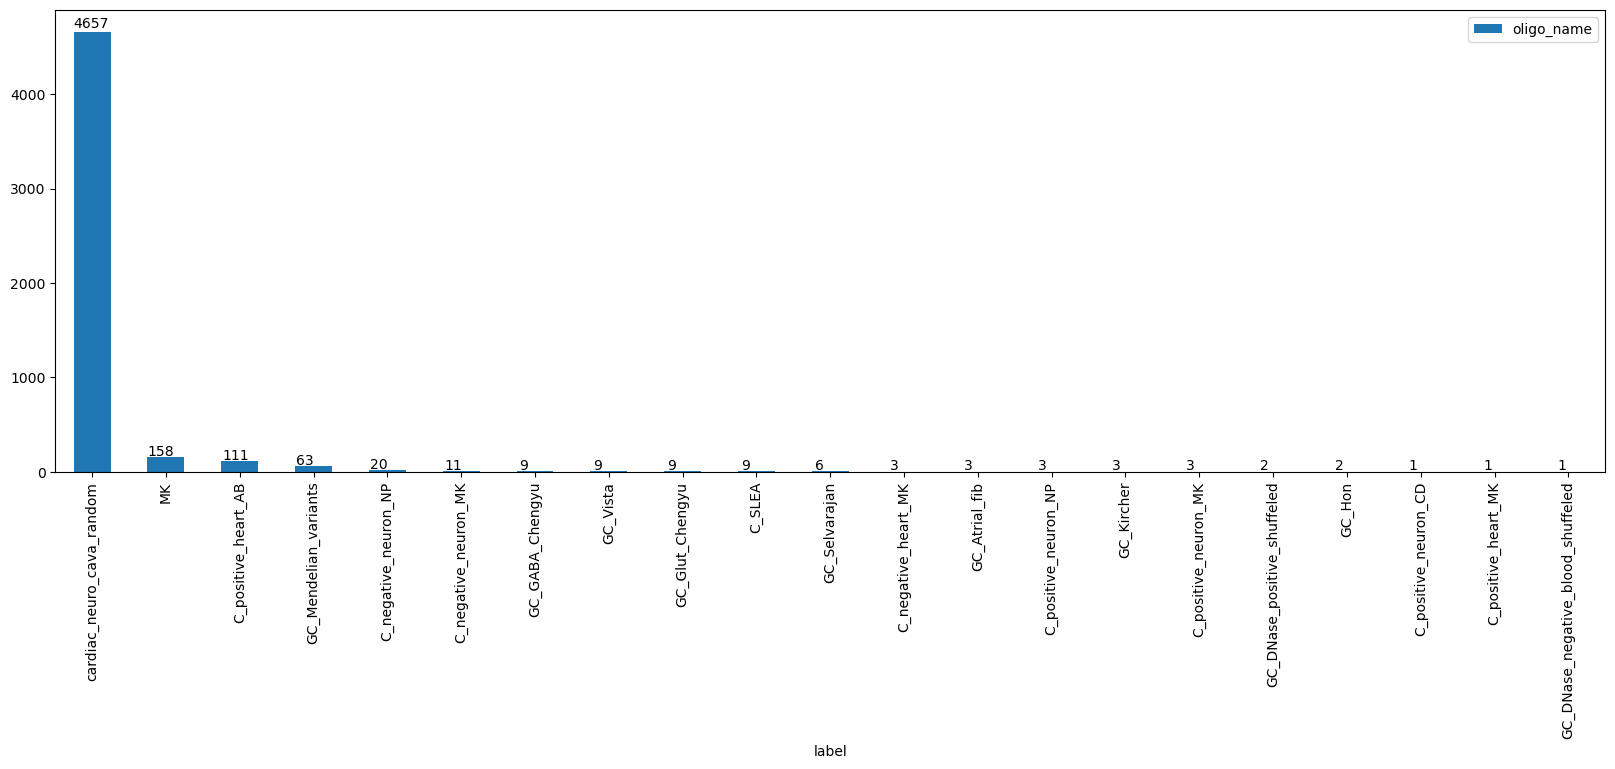

In [ ]:
# plot the counts per label


sorted_missing_seqs = missing_seqs.groupby('label').count().sort_values(by='oligo_name', ascending=False)
ax = sorted_missing_seqs.plot(kind='bar', figsize=(20, 6))
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, (p.get_height() + 15) * 1.005))

## Which sequences are this exactly?
- Perpare list of unmapped sequenes
- Take two sequences by random and match them to the reference
- Write function which produces fasta file for the unmapped sequences
  - Iterate over reference.fa and take only the list of the unmapped sequences

In [ ]:
# missing_seqs['oligo_name']
import yaml
# load reference fasta specified in config
config_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/config.yaml'
assignment_name = 'assignIGVFDesignNoTemp'

with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()
ref_fasta_path = config['assignments'][assignment_name]['reference']




In [ ]:
len(missing_seqs['oligo_name'].values.tolist()) # 5084

5084

In [ ]:
# subsampled data (400 lines)
# ref_fasta_path = '/data/gpfs-1/users/kisa11_c/work/coding/tmp_data/tmp_ref_no_dup.fa'
missing_seqs_list = missing_seqs['oligo_name'].values.tolist()
missing_seq_dict = prepare_missing_seq_dict(ref_fasta_path, missing_seqs_list)

In [ ]:
len(missing_seq_dict)
missing_seq_dict.values()

{'>cardiac_neuro_cava_random:PRDM16|ENSG00000142611.17|EH38E2779764_fwd_tile1-1': 'AGGACCGGATCAACTGCCGCCCAGGAGCTCTCGTGCATCCACTCTGGTCCTCCGGTCCCGGCTGCGCCTCTTGCACCAGGCTGGGGCAGGGATTACCAGCCGCACGCAGGCTGCGGGAACCCCCTTTGTCTGGCTTTCGGCGGAGTCGGCAGAGTTCCTTCCTTCTGGGCTAATGCCCAGTTTAATTGTACATCCCATTGTGTCGTCTCTGTTCAATCATGTTCAAAAATACCTACGTCCACTCCGTTCCCATTTAGATCTCTCTAAAGTCCATTCCGGCTTATCCATTGCGTGAACCGA',
 '>cardiac_neuro_cava_random:SZT2|ENSG00000198198.17|EH38E2807306_fwd_tile1-1': 'AGGACCGGATCAACTGGGGGCGTGTGGTGGGTGGGGGGTGGGTGTTGCTAATTTAGACTGAGTGGCCAGGAAAAGCCTCACCAGGGAGGTGACAGATAAGCCGAGATCTAAATGGCAAGAAGGAATGAGTCACATGAAGACCTACAGTCAGAGCAATCCAGGGCAAAGGCAAAGTGCAAAGATAGCACATTTGGCATATCTATGGCACAGAAAGAAGGCCTGTGCGGATGAAGGGTGATAAACTGGCATGAGAATCATAAGAGATGAGAATGGCAAGGCAAGGAGCATTGCGTGAACCGA',
 '>cardiac_neuro_cava_random:ST3GAL3|ENSG00000126091.21|EH38E2807766_fwd_tile1-1': 'AGGACCGGATCAACTCCCCAACCTCTCTCACGTACACCTGCGTGTTCATGTACACATACATGTACATAGCATCCCTTGAGCTGTCCTCACCTGACCTACTGAACTCTGAGGTGGTCCGGGTCCCCCAGAGATGGCTGGGTAGCTGG

In [ ]:
## fastq files
# /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/assignment/assignIGVFDesignNoTemp/fastq/merge_split0.join.fastq.gz

merged_reads = ["merge_split0.join.fastq.gz", "merge_split13.join.fastq.gz", "merge_split18.join.fastq.gz", "merge_split22.join.fastq.gz", "merge_split27.join.fastq.gz", "merge_split5.join.fastq.gz", "merge_split1.join.fastq.gz", "merge_split14.join.fastq.gz", "merge_split19.join.fastq.gz", "merge_split23.join.fastq.gz", "merge_split28.join.fastq.gz", "merge_split6.join.fastq.gz", "merge_split10.join.fastq.gz", "merge_split15.join.fastq.gz", "merge_split2.join.fastq.gz", "merge_split24.join.fastq.gz", "merge_split29.join.fastq.gz", "merge_split7.join.fastq.gz", "merge_split11.join.fastq.gz", "merge_split16.join.fastq.gz", "merge_split20.join.fastq.gz", "merge_split25.join.fastq.gz", "merge_split3.join.fastq.gz", "merge_split8.join.fastq.gz", "merge_split12.join.fastq.gz", "merge_split17.join.fastq.gz", "merge_split21.join.fastq.gz", "merge_split26.join.fastq.gz", "merge_split4.join.fastq.gz", "merge_split9.join.fastq.gz"]

In [ ]:
def prep_query_seq(seq, length, reverse=False):
    '''
    Prepares the query sequence for the search
    @param: sequence with full length; length: disired length; reverse: bool if reverse sequence is required
    @output: query sequence
    '''
    if reverse:
        query_seq = seq[::-1]
    return seq[:length]
        
# feature assignment exact matches 
def exact_match(fastq_file_path, seq_dict, seq_length, reverse=False):
    '''Tries to find all sequences in one read sequence. Iterates each missing sequence for an exact match. The sequence length is given by the user.'''
    seperation = ''.join(['-'] * 20)
    counter = 0
    with gzip.open(fastq_file_path, 'rt') as reads_fastq:
        with open(_output_file_path, 'w') as output_file:
            for line in reads_fastq:
                if line.startswith('@'):
                    header = line
                elif line.startswith('+'):
                    pass
                else:
                    read_seq = line
                    for header, seq in seq_dict.items():
                        query_seq = prep_query_seq(seq, seq_length, reverse)
                        if query_seq in read_seq:
                            counter += 1
                            output_file.write(f'{seperation}\n\nFound match\n')
                            output_file.write(f'In header: {header}\n')
                            output_file.write(f'match of length {seq_length} of\nquery: {header}\n\nseq:{query_seq}\n\n')
                            output_file.write(f'in sequence: {read_seq}\n')
                            output_file.write(f'{seperation}\n')
                            # print(f'{seperation}\n\nFound match\n')
                            # print('In header: ',header)
                            # print(f'match of length {seq_length} of ', query_seq)
                            # print('in sequence: ', seq)
                            # print(f'{seperation}')
            output_file.write(f'Found {counter} matches in {fastq_file_path}\n')
    print(f'Found {counter} matches')
# main

In [ ]:
    test_search_dict = {
        'search header': 'TCCCAGGTGAGATGGGGAGGTGAGTAGCAGATGATCTCGTGGAAGCTCCTCACCAACCTCCATCCTCTCAGTTCCTGGAAGATCACAGGGTGTTCTGTGAAGACTCAGAT'
    }
    # test_path = '/home/kisa/coding/scripts/test.fastq'
    merged_reads_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/assignment/assignIGVFDesignNoTemp/fastq/merge_split0.join.fastq.gz'
    exact_match(merged_reads_path, missing_seq_dict, 110, False)

NameError: name 'exact_match' is not defined

In [ ]:
import json 
json.dump(missing_seq_dict, open('/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/missing_seq_dict.json', 'w+'))

## Filter reference_exact for missing sequences


In [ ]:
# write missing sequences to file (.fa)
import json 
missing_seq_dict = json.load(open('/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/missing_seq_dict.json', 'r'))

In [ ]:
with open('/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/all_missing_sequences.fa', 'w') as missing_seq_file:
    for header, seq in missing_seq_dict.items():
        missing_seq_file.write(f'{header}\n{seq}\n')
    